# Multiple Variable Linear Regression

## Goals
In this lab you will:
- Extend our regression model to support multiple features
- Extend data structures to support multiple features
- Rewrite prediction, cost and gradient routines to support multiple features
- Utilize NumPy `np.dot` to vectorize their implementations for speed and simplicity

## Tools
- NumPy — scientific computing
- Pandas — load data
- Matplotlib — plotting

In [1]:
import copy, math
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12

In [2]:
df = pd.read_csv('../data/multivariate.csv')

print(f"Shape: {df.shape}")
print("\nHead:\n", df.head())
print("\nDescribe:\n", df.describe())

Shape: (100, 4)

Head:
    size_sqm  bedrooms  age_years  price_uds
0       209         2         32     328317
1       247         2          7     399261
2       209         2          4     332917
3       296         3         38     462306
4       117         5          3     227808

Describe:
          size_sqm    bedrooms   age_years      price_uds
count  100.000000  100.000000  100.000000     100.000000
mean   184.990000    2.890000   20.280000  302309.190000
std     63.573944    1.420592   11.986592   95634.990702
min     51.000000    1.000000    0.000000   74717.000000
25%    144.250000    2.000000   11.000000  243366.750000
50%    193.500000    3.000000   22.000000  310528.500000
75%    234.500000    4.000000   31.000000  377409.000000
max    298.000000    5.000000   39.000000  483832.000000


In [4]:
X_train = df[['size_sqm', 'bedrooms', 'age_years']].values
y_train = df['price_uds'].values

m, n = X_train.shape
print(f"\n✓ X_train shape: {X_train.shape}, (m): {m} examples {n} features")
print(f"\n✓ y_train shape: {y_train.shape}")
print("\n✓ First 5 examples (X_train):\n", X_train[:5])
print("\n✓ First 5 examples (y_train):\n", y_train[:5])


✓ X_train shape: (100, 3), (m): 100 examples 3 features

✓ y_train shape: (100,)

✓ First 5 examples (X_train):
 [[209   2  32]
 [247   2   7]
 [209   2   4]
 [296   3  38]
 [117   5   3]]

✓ First 5 examples (y_train):
 [328317 399261 332917 462306 227808]


In [5]:
b_init = 0
w_init = np.zeros(n)

print(f"w_init shape: {w_init.shape}, -> one weight per feature")
print(f"w_init: {w_init}")
print(f"b_init type: {type(b_init)}, value {b_init}")

w_init shape: (3,), -> one weight per feature
w_init: [0. 0. 0.]
b_init type: <class 'int'>, value 0


In [6]:
def predict(x, w, b):

    f_wb = np.dot(x, w) + b
    return f_wb

#Test predict function
x_test = X_train[0]
pred_test = predict(x_test, w_init, b_init)

print(f"x: {x_test}")
print(f"Predicted value (with w_init, b_init): {pred_test:.2f}")
print(f"Actual value: {y_train[0]:.2f}")

x: [209   2  32]
Predicted value (with w_init, b_init): 0.00
Actual value: 328317.00


In [ ]:
def compute_cost(X, y, w, b):

    m = X.shape[0]
    cost_sum = 0

    for i in range(m):
        f_wb_i = np.dot(X[i], w) + b
        cost_sum += (f_wb_i - y[i]) ** 2

    total_cost = cost_sum / (2*m)
    return total_cost


#Test
cost = compute_cost(X_train, y_train, w_init, b_init)
print(f"Cost at initial w {w_init} and b {b_init} (zeros): {cost:.2f}")

Cost at initial w [0. 0. 0.] and b 0 (zeros): 50222718645.25


In [9]:
def compute_gradient(X, y, w, b):

    m, n = X.shape
    dj_dw = np.zeros((n,))
    dj_db = 0.

    for i in range(m):
        err = (np.dot(X[i], w) + b) - y[i]
        for j in range(n):
            dj_dw[j] += err * X[i][j]
        dj_db += err
    
    dj_dw /= m
    dj_db /= m

    return dj_dw, dj_db

# Test
dj_dw, dj_db = compute_gradient(X_train, y_train, w_init, b_init)
print(f"dj_db at w=zeros: {dj_db:.4f}")
print(f"dj_dw at w=zeros: {dj_dw}")

dj_db at w=zeros: -302309.1900
dj_dw at w=zeros: [-61879696.33   -893069.26  -6157358.49]


In [10]:
def gradient_descent(X, y, w_in, b_in, alpha, num_iters, compute_cost, compute_gradient):

    J_history = []
    w = copy.deepcopy(w_in)
    b = b_in

    for i in range(num_iters):
        dj_dw, dj_db = compute_gradient(X, y, w, b)

        w = w - alpha * dj_dw
        b = b - alpha * dj_db

        if i < 100000:  # Prevent resource exhaustion
            cost = compute_cost(X, y, w, b)
            J_history.append(cost)
        
        if i % math.ceil(num_iters / 10) == 0:
            print(f"Iteration {i:4d}: Cost {cost:.4f}   ")

    return w, b, J_history



In [11]:
#Hyperparameters
initial_w = np.zeros(n)
initial_b = 0
iterations = 1000
alpha = 5.0e-7

w_final, b_final, J_history = gradient_descent(X_train, y_train, initial_w, initial_b, alpha, iterations, compute_cost, compute_gradient)
print(f"(w,b) found by gradient descent: ({w_final},{b_final})")

Iteration    0: Cost 48307439417.2297   
Iteration  100: Cost 1116263003.5564   
Iteration  200: Cost 160165276.5438   
Iteration  300: Cost 140575754.3396   
Iteration  400: Cost 139958707.6390   
Iteration  500: Cost 139729130.3543   
Iteration  600: Cost 139510524.7519   
Iteration  700: Cost 139295212.6007   
Iteration  800: Cost 139082987.0887   
Iteration  900: Cost 138873793.5988   
(w,b) found by gradient descent: ([1605.21834397   34.32731651  130.27612359],9.055235672263153)


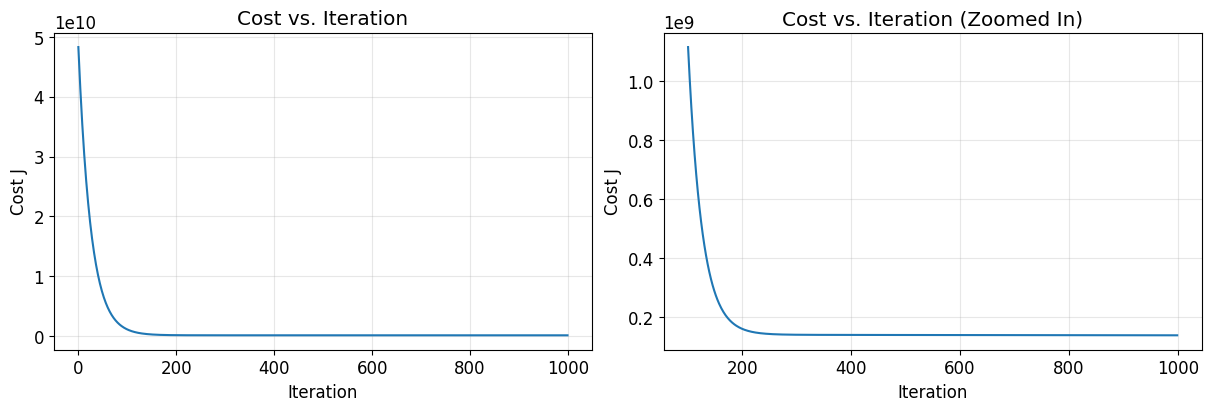

In [13]:
fig, (ax1, ax2) = plt.subplots(1, 2, constrained_layout=True, figsize=(12, 4))

ax1.plot(J_history)
ax1.set_xlabel("Iteration")
ax1.set_ylabel("Cost J")
ax1.set_title("Cost vs. Iteration")
ax1.grid(True, alpha=0.3)

ax2.plot(100 + np.arange(len(J_history[100:])), J_history[100:])
ax2.set_xlabel("Iteration")
ax2.set_ylabel("Cost J")
ax2.set_title("Cost vs. Iteration (Zoomed In)")
ax2.grid(True, alpha=0.3)

plt.show()

In [15]:
#Predictions

for i in range(5, m):
    pred = np.dot(X_train[i], w_final) + b_final
    print(f"Example {i}: Predicted price: ${pred:,.2f}, Actual price: ${y_train[i]:,.2f}")

Example 5: Predicted price: $373,105.42, Actual price: $362,474.00
Example 6: Predicted price: $408,699.95, Actual price: $402,767.00
Example 7: Predicted price: $377,837.26, Actual price: $348,825.00
Example 8: Predicted price: $280,673.31, Actual price: $285,668.00
Example 9: Predicted price: $316,536.51, Actual price: $290,245.00
Example 10: Predicted price: $141,788.83, Actual price: $177,708.00
Example 11: Predicted price: $118,890.62, Actual price: $151,838.00
Example 12: Predicted price: $193,305.81, Actual price: $191,912.00
Example 13: Predicted price: $267,249.38, Actual price: $259,043.00
Example 14: Predicted price: $238,094.90, Actual price: $233,087.00
Example 15: Predicted price: $398,980.27, Actual price: $399,228.00
Example 16: Predicted price: $425,801.92, Actual price: $421,540.00
Example 17: Predicted price: $305,149.99, Actual price: $305,664.00
Example 18: Predicted price: $468,778.73, Actual price: $471,500.00
Example 19: Predicted price: $313,176.08, Actual pric